In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
sns.set_theme(style="whitegrid", context="talk")
print("Imports loaded.")


Imports loaded.


In [2]:
df = pd.read_csv('hand_gesture_clean_labeled.csv')
print(f"Shape: {df.shape}")
drop_cols = [c for c in ['person_name', 'gesture_label.1', 'gesture', 'output_label'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Dropped: {drop_cols}")
print(f"Unique persons: {df['person_id'].nunique()}")
dist_cols = [c for c in df.columns if c.startswith("dist_")]
X = df[dist_cols].values
print(f"Samples: {len(df)}, Features: {len(dist_cols)}")


Shape: (5226, 214)
Dropped: ['person_name', 'gesture_label.1']
Unique persons: 102
Samples: 5226, Features: 210


In [3]:
le_person = LabelEncoder()
df['person_encoded'] = le_person.fit_transform(df['person_id'])
y = df['person_encoded'].values
n_classes = len(np.unique(y))
print(f"Encoded person classes: 0-{n_classes-1} ({n_classes} persons)")


Encoded person classes: 0-101 (102 persons)


In [4]:
def get_model(name):
    if name == "Naive Bayes": return GaussianNB()
    elif name == "Decision Tree": return DecisionTreeClassifier(random_state=42)
    elif name == "XGBoost": return XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                             eval_metric='mlogloss', random_state=42, verbosity=0)
    elif name == "Random Forest": return RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
    elif name == "KNN": return KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    elif name == "Logistic Regression": return LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
    elif name == "SVM": return LinearSVC(max_iter=2000, random_state=42, dual=False)

model_names = ["Naive Bayes", "Decision Tree", "XGBoost", "Random Forest",
               "KNN", "Logistic Regression", "SVM"]
model_order = list(model_names)


In [5]:
def scale_and_predict(model, X_tr, X_te, y_train, y_test, name):
    if name in ["Logistic Regression", "SVM", "KNN"]:
        X_tr_s = std_scaler.transform(X_tr)
        X_te_s = std_scaler.transform(X_te)
    elif name == "Naive Bayes":
        X_tr_s = mm_scaler.transform(X_tr)
        X_te_s = mm_scaler.transform(X_te)
    else:
        X_tr_s, X_te_s = X_tr, X_te
    model.fit(X_tr_s, y_train)
    preds = model.predict(X_te_s)
    return [accuracy_score(y_test, preds),
            precision_score(y_test, preds, average="weighted", zero_division=0),
            recall_score(y_test, preds, average="weighted", zero_division=0),
            f1_score(y_test, preds, average="weighted", zero_division=0)]


## 2.1 Variation of Training Ratio (Fixed Data Size = 100%)

In [6]:
ratios = [0.5, 0.6, 0.7, 0.8]
results_2_1 = []
t0 = time.time()
for ratio in ratios:
    tp = int(ratio * 100)
    print(f"\n--- Split {tp}-{100-tp} ---")
    ss = ShuffleSplit(n_splits=3, train_size=ratio, random_state=42)
    for fold, (tr_idx, te_idx) in enumerate(ss.split(X, y), 1):
        ft = time.time()
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        std_scaler = StandardScaler().fit(X_tr)
        mm_scaler = MinMaxScaler().fit(X_tr)
        for name in model_names:
            try:
                model = get_model(name)
                m = scale_and_predict(model, X_tr, X_te, y_tr, y_te, name)
                results_2_1.append([f"{tp}-{100-tp}", name] + m)
            except Exception as e:
                print(f"  {name} err: {e}")
                results_2_1.append([f"{tp}-{100-tp}", name, 0.0, 0.0, 0.0, 0.0])
        print(f"  Fold {fold}: {time.time()-ft:.0f}s")
    print()
df_2_1 = pd.DataFrame(results_2_1, columns=["Split","Model","Accuracy","Precision","Recall","F1"])
print(f"\nDone in {time.time()-t0:.0f}s")



--- Split 50-50 ---


  Fold 1: 87s


  Fold 2: 73s


  Fold 3: 69s


--- Split 60-40 ---


  Fold 1: 78s


...

  Fold 2: 101s


  Fold 3: 98s


--- Split 80-20 ---


  Fold 1: 98s


  Fold 2: 93s


  Fold 3: 97s


Done in 1061s


In [7]:
df_2_1.to_csv("Experiment2_PersonID_TrainingRatio.csv", index=False)
final_2_1 = df_2_1.groupby(["Split","Model"], as_index=False).mean().round(4)
print(final_2_1.to_string())


    Split                Model  Accuracy  Precision  Recall      F1
0   50-50        Decision Tree    0.7922     0.8030  0.7922  0.7909
1   50-50                  KNN    0.8895     0.9048  0.8895  0.8867
2   50-50  Logistic Regression    0.8547     0.8693  0.8547  0.8533
3   50-50          Naive Bayes    0.2859     0.3905  0.2859  0.2884
4   50-50        Random Forest    0.9731     0.9751  0.9731  0.9729
5   50-50                  SVM    0.9348     0.9403  0.9348  0.9340
6   50-50              XGBoost    0.9203     0.9257  0.9203  0.9200
7   60-40        Decision Tree    0.8240     0.8345  0.8240  0.8235
8   60-40                  KNN    0.9442     0.9506  0.9442  0.9429
9   60-40  Logistic Regression    0.8884     0.9006  0.8884  0.8874
10  60-40          Naive Bayes    0.2897     0.3945  0.2897  0.2874
11  60-40        Random Forest    0.9782     0.9796  0.9782  0.9781
12  60-40                  SVM    0.9487     0.9533  0.9487  0.9477
13  60-40              XGBoost    0.9364     0.9

## 2.2 Variation of Data Size (Fixed Training Ratio = 80-20)

In [8]:
data_sizes = [0.4, 0.6, 0.8, 1.0]
results_2_2 = []
for size in data_sizes:
    sp = int(size * 100)
    print(f"\n--- Data Size {sp}% ---")
    df_s = df.groupby("person_encoded", group_keys=False).apply(lambda x: x.sample(frac=size, random_state=42))
    X_s, y_s = df_s[dist_cols].values, df_s['person_encoded'].values
    ss = ShuffleSplit(n_splits=3, train_size=0.8, random_state=42)
    for fold, (tr_idx, te_idx) in enumerate(ss.split(X_s, y_s), 1):
        ft = time.time()
        X_tr, X_te = X_s[tr_idx], X_s[te_idx]
        y_tr, y_te = y_s[tr_idx], y_s[te_idx]
        std_scaler = StandardScaler().fit(X_tr)
        mm_scaler = MinMaxScaler().fit(X_tr)
        for name in model_names:
            try:
                model = get_model(name)
                m = scale_and_predict(model, X_tr, X_te, y_tr, y_te, name)
                results_2_2.append([f"{sp}%", name] + m)
            except Exception as e:
                print(f"  {name} err: {e}")
                results_2_2.append([f"{sp}%", name, 0.0, 0.0, 0.0, 0.0])
        print(f"  Fold {fold}: {time.time()-ft:.0f}s")
df_2_2 = pd.DataFrame(results_2_2, columns=["Data_Size","Model","Accuracy","Precision","Recall","F1"])
print("Done!")



--- Data Size 40% ---


  Fold 1: 52s


  Fold 2: 57s


  Fold 3: 69s

--- Data Size 60% ---


  Fold 1: 87s


...

  Fold 2: 101s


  Fold 3: 103s

--- Data Size 100% ---


  Fold 1: 109s


  Fold 2: 109s


  Fold 3: 110s
Done!


In [9]:
df_2_2.to_csv("Experiment2_PersonID_DataSize.csv", index=False)
final_2_2 = df_2_2.groupby(["Data_Size","Model"], as_index=False).mean().round(4)
print(final_2_2.to_string())


   Data_Size                Model  Accuracy  Precision  Recall      F1
0       100%        Decision Tree    0.8550     0.8700  0.8550  0.8538
1       100%                  KNN    0.9643     0.9691  0.9643  0.9639
2       100%  Logistic Regression    0.9229     0.9326  0.9229  0.9220
3       100%          Naive Bayes    0.2859     0.3677  0.2859  0.2804
4       100%        Random Forest    0.9863     0.9878  0.9863  0.9863
5       100%                  SVM    0.9646     0.9693  0.9646  0.9643
6       100%              XGBoost    0.9506     0.9544  0.9506  0.9502
7        40%        Decision Tree    0.6897     0.7582  0.6897  0.6918
8        40%                  KNN    0.6261     0.7392  0.6261  0.6271
9        40%  Logistic Regression    0.7971     0.8508  0.7971  0.7966
10       40%          Naive Bayes    0.2761     0.3585  0.2761  0.2774
11       40%        Random Forest    0.9499     0.9639  0.9499  0.9497
12       40%                  SVM    0.8862     0.9165  0.8862  0.8883
13    

In [10]:
# ====== PLOTTING FUNCTIONS ======
def bar_plot(df, x_col, title, xlabel, fn, ylim=(0.5,1.05)):
    fig, axs = plt.subplots(2,2,figsize=(16,10))
    for i,met in enumerate(["Accuracy","Precision","Recall","F1"]):
        sns.barplot(data=df, x=x_col, y=met, hue="Model", hue_order=model_order,
                    errorbar=None, palette="tab10", ax=axs[i//2,i%2])
        axs[i//2,i%2].set_title(f"{met} vs {title}", fontweight="bold")
        axs[i//2,i%2].set_ylim(*ylim); axs[i//2,i%2].legend_.remove(); axs[i//2,i%2].set_xlabel(xlabel)
    h,_ = axs[0,0].get_legend_handles_labels()
    fig.legend(h, model_order, title="Model", loc="center left", bbox_to_anchor=(1.02,0.5))
    plt.suptitle(f"Person ID - {title}", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0,0,1,1]); plt.savefig(fn, dpi=300, bbox_inches='tight'); plt.show()

def line_plot(df, x_col, title, xlabel, fn, ylim=(0.5,1.05)):
    fig, axs = plt.subplots(2,2,figsize=(14,10))
    for i,met in enumerate(["Accuracy","Precision","Recall","F1"]):
        piv = df.pivot_table(index=x_col, columns="Model", values=met, aggfunc="mean")
        piv.plot(marker="o", ax=axs[i//2,i%2])
        axs[i//2,i%2].set_title(f"{met} Trend", fontweight="bold")
        axs[i//2,i%2].set_ylim(*ylim); axs[i//2,i%2].legend_.remove()
        axs[i//2,i%2].set_xlabel(xlabel); axs[i//2,i%2].grid(True, alpha=0.3)
    h,_ = axs[0,0].get_legend_handles_labels()
    fig.legend(h, model_order, title="Model", loc="center left", bbox_to_anchor=(1.02,0.5))
    plt.suptitle(f"Person ID - {title} Trend", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0,0,1,1]); plt.savefig(fn, dpi=300, bbox_inches='tight'); plt.show()

def box_plot(df, x_col, title, fn, ylim=(0.5,1.05)):
    fig, axs = plt.subplots(2,2,figsize=(16,10))
    for i,met in enumerate(["Accuracy","Precision","Recall","F1"]):
        sns.boxplot(data=df, x=x_col, y=met, hue="Model", hue_order=model_order,
                    palette="tab10", ax=axs[i//2,i%2])
        axs[i//2,i%2].set_title(f"{met} Distribution", fontweight="bold")
        axs[i//2,i%2].set_ylim(*ylim); axs[i//2,i%2].legend_.remove()
    h,_ = axs[0,0].get_legend_handles_labels()
    fig.legend(h, model_order, title="Model", loc="center left", bbox_to_anchor=(1.02,0.5))
    plt.suptitle(f"Person ID - {title} (Fold Variance)", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0,0,1,1]); plt.savefig(fn, dpi=300, bbox_inches='tight'); plt.show()

def rank_plot(df, title, fn):
    best = df.groupby("Model")["Accuracy"].max().sort_values(ascending=False)
    fig,ax = plt.subplots(figsize=(10,5))
    colors = ["#2ecc71" if i==0 else "#95a5a6" for i in range(len(best))]
    bars = ax.barh(best.index, best.values, color=colors)
    for b,v in zip(bars,best.values): ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.4f}", va="center")
    ax.set_xlim(0,1.05); ax.set_xlabel("Best Accuracy")
    ax.set_title(f"Model Ranking - {title}", fontweight="bold")
    plt.tight_layout(); plt.savefig(fn, dpi=300, bbox_inches='tight'); plt.show()

def heat_plot(df, x_col, title, fn):
    fig, axs = plt.subplots(2,2,figsize=(14,10))
    for i,met in enumerate(["Accuracy","Precision","Recall","F1"]):
        piv = df.pivot_table(index="Model", columns=x_col, values=met, aggfunc="mean")
        sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5, ax=axs[i//2,i%2])
        axs[i//2,i%2].set_title(f"{met} Heatmap", fontweight="bold")
    plt.suptitle(f"Person ID - {title}", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig(fn, dpi=300, bbox_inches='tight'); plt.show()

def summary_stats(df, group_col, title):
    print("="*90); print(f"SUMMARY - {title}"); print("="*90)
    s = df.groupby(["Model",group_col]).agg(
        Mean_Acc=("Accuracy","mean"),Std_Acc=("Accuracy","std"),
        Mean_Prec=("Precision","mean"),Mean_Rec=("Recall","mean"),Mean_F1=("F1","mean")).round(4)
    print(s.to_string())
    best = df.groupby("Model")["Accuracy"].max().sort_values(ascending=False)
    print(f"\nBEST: {best.index[0]} ({best.iloc[0]:.4f}) | WORST: {best.index[-1]} ({best.iloc[-1]:.4f})\n")


## Visualizations: Training Ratio Variation

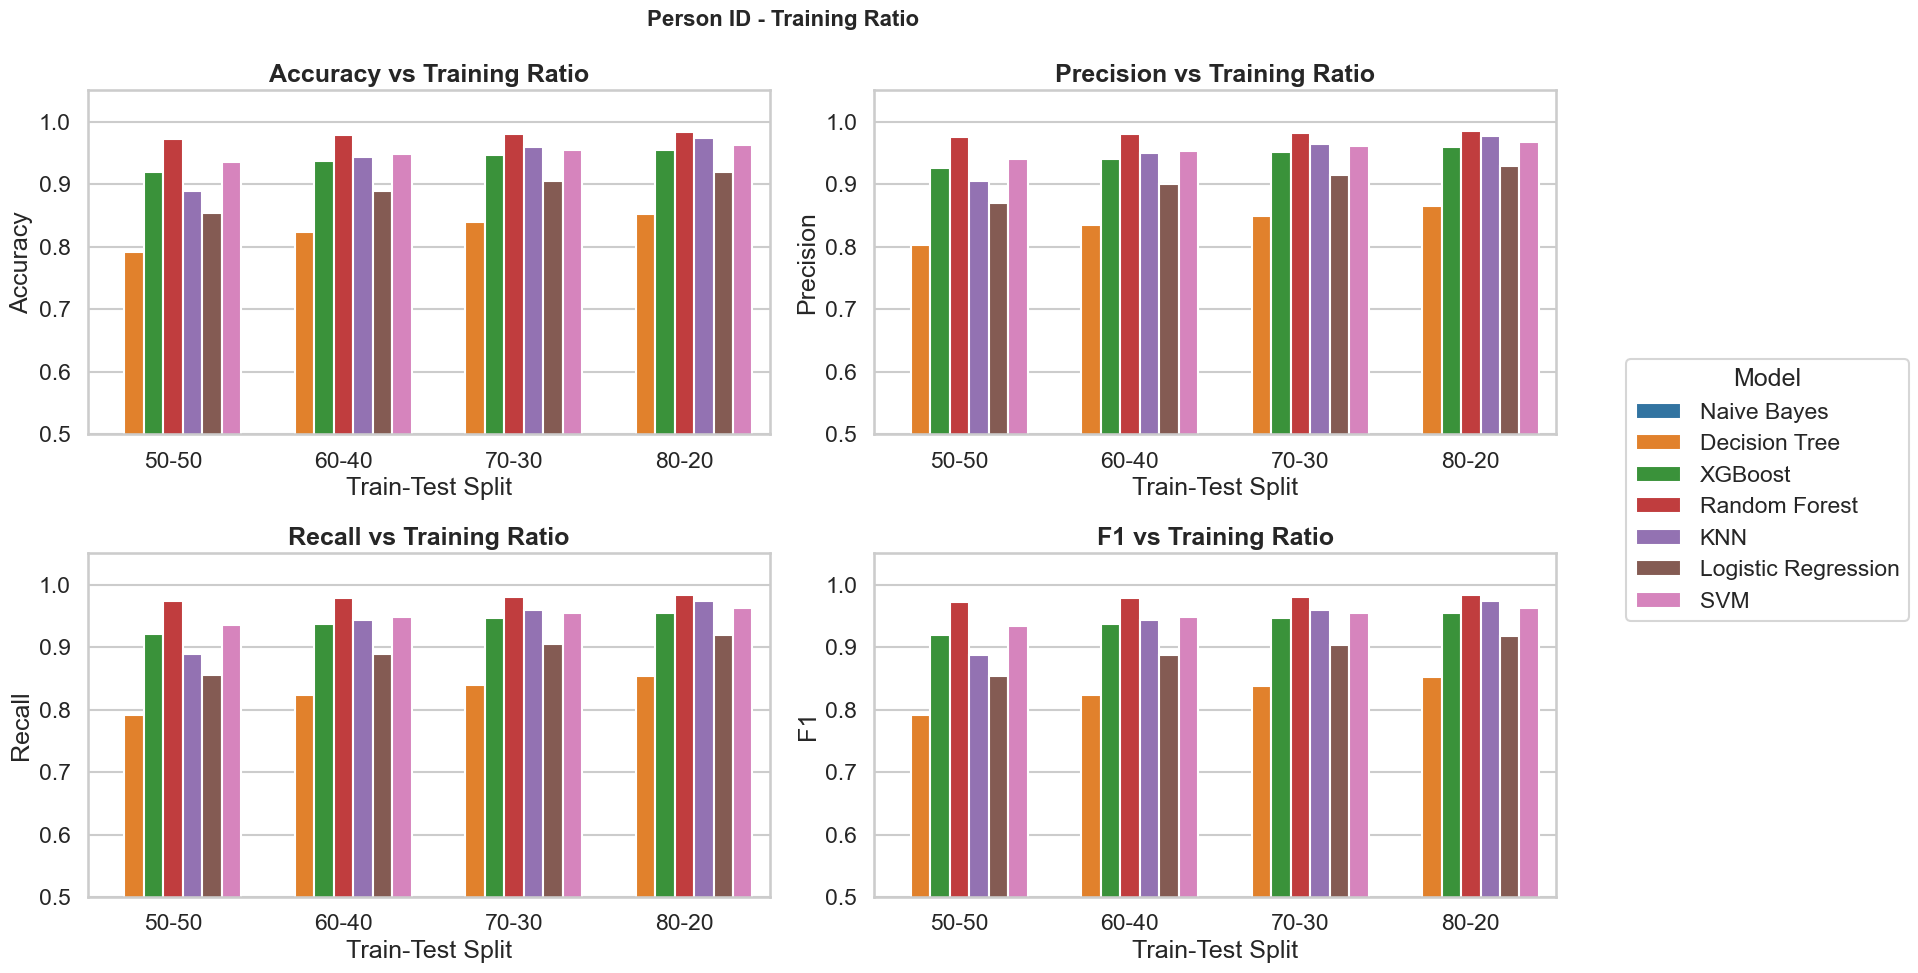

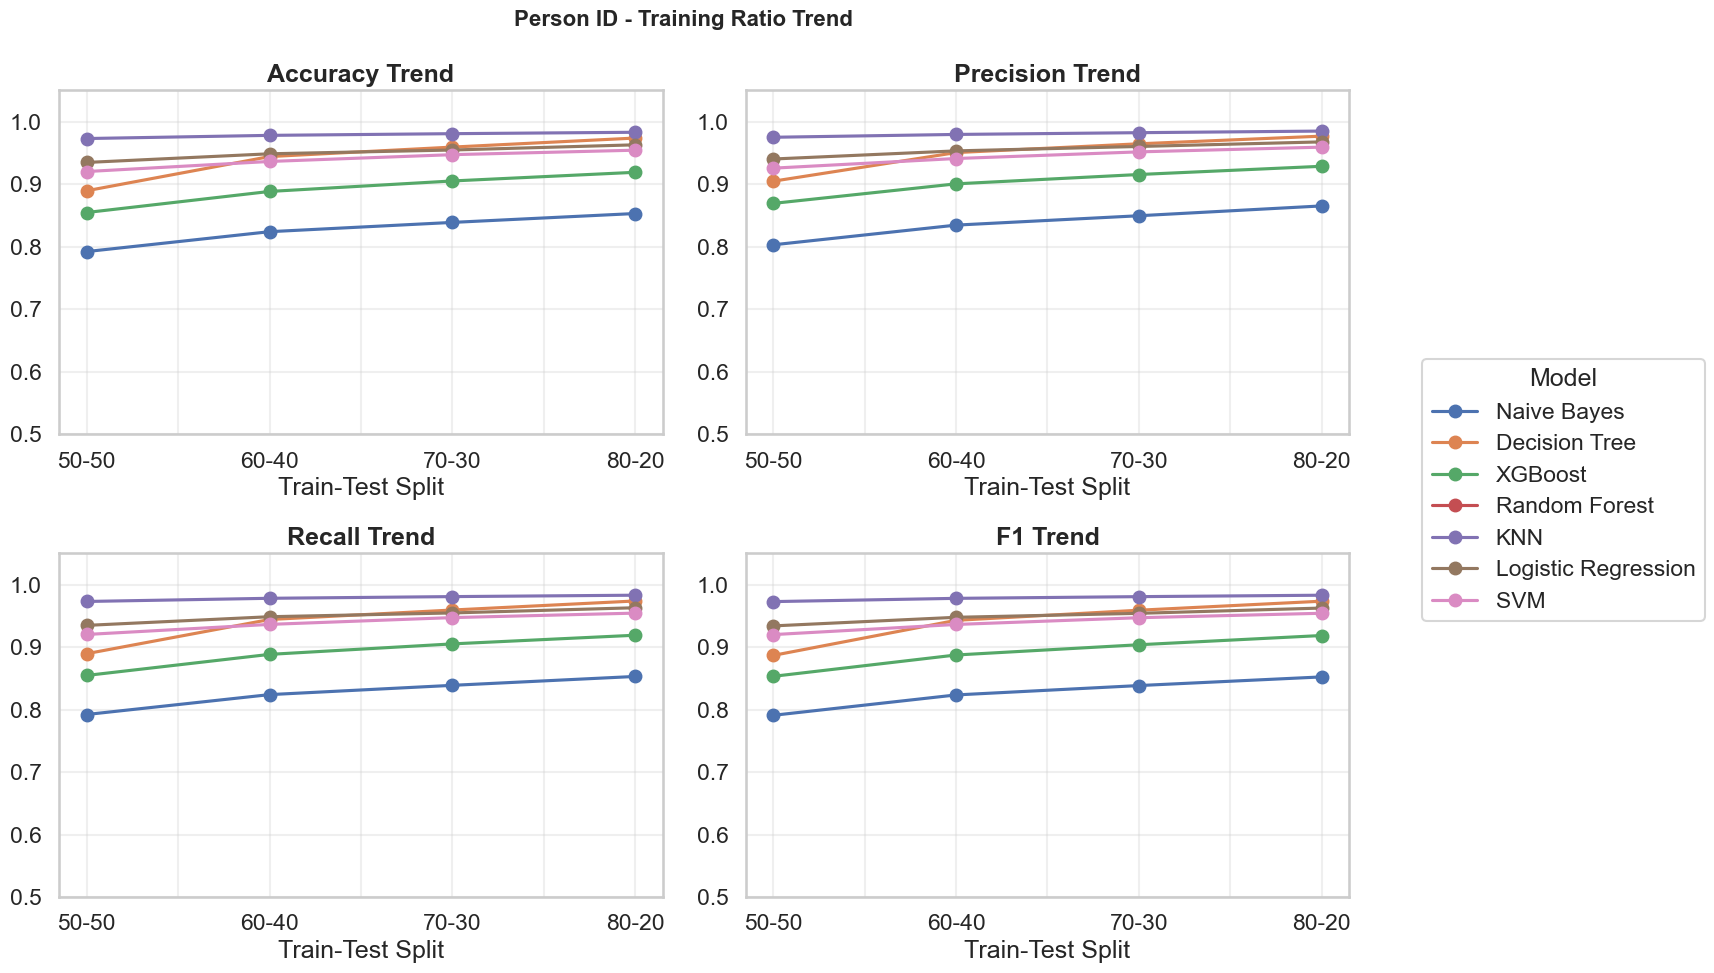

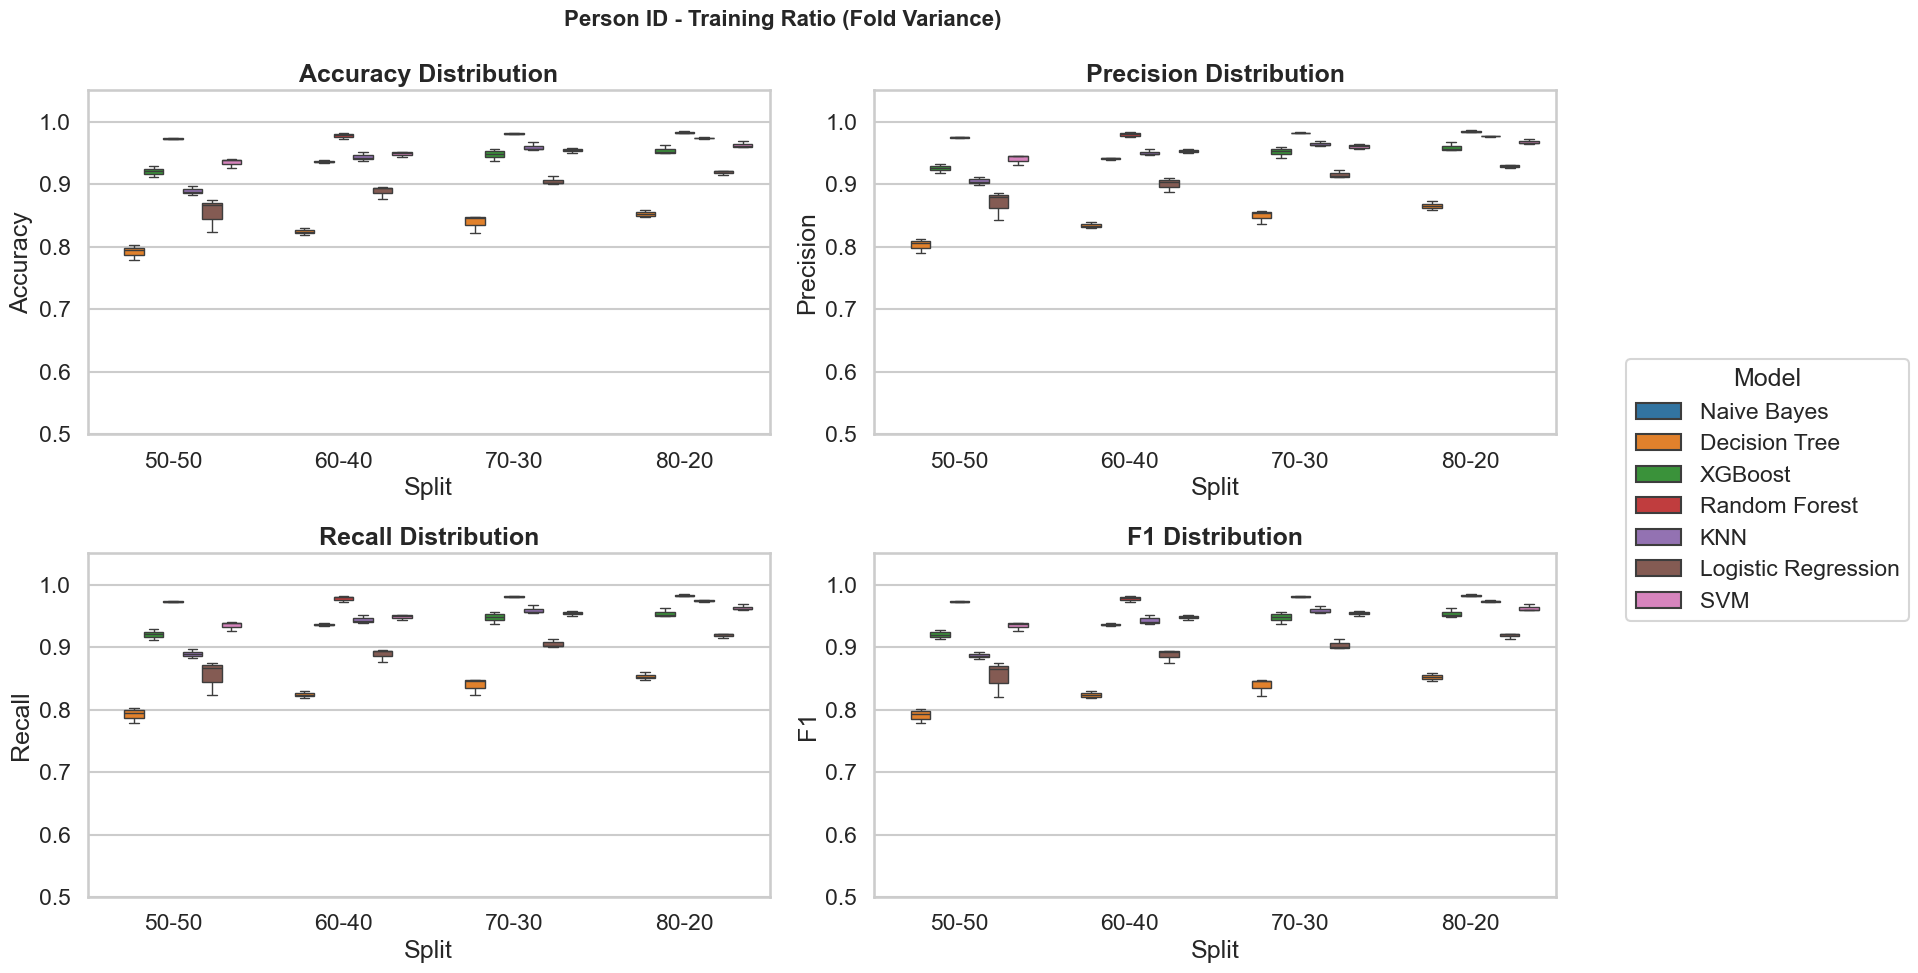

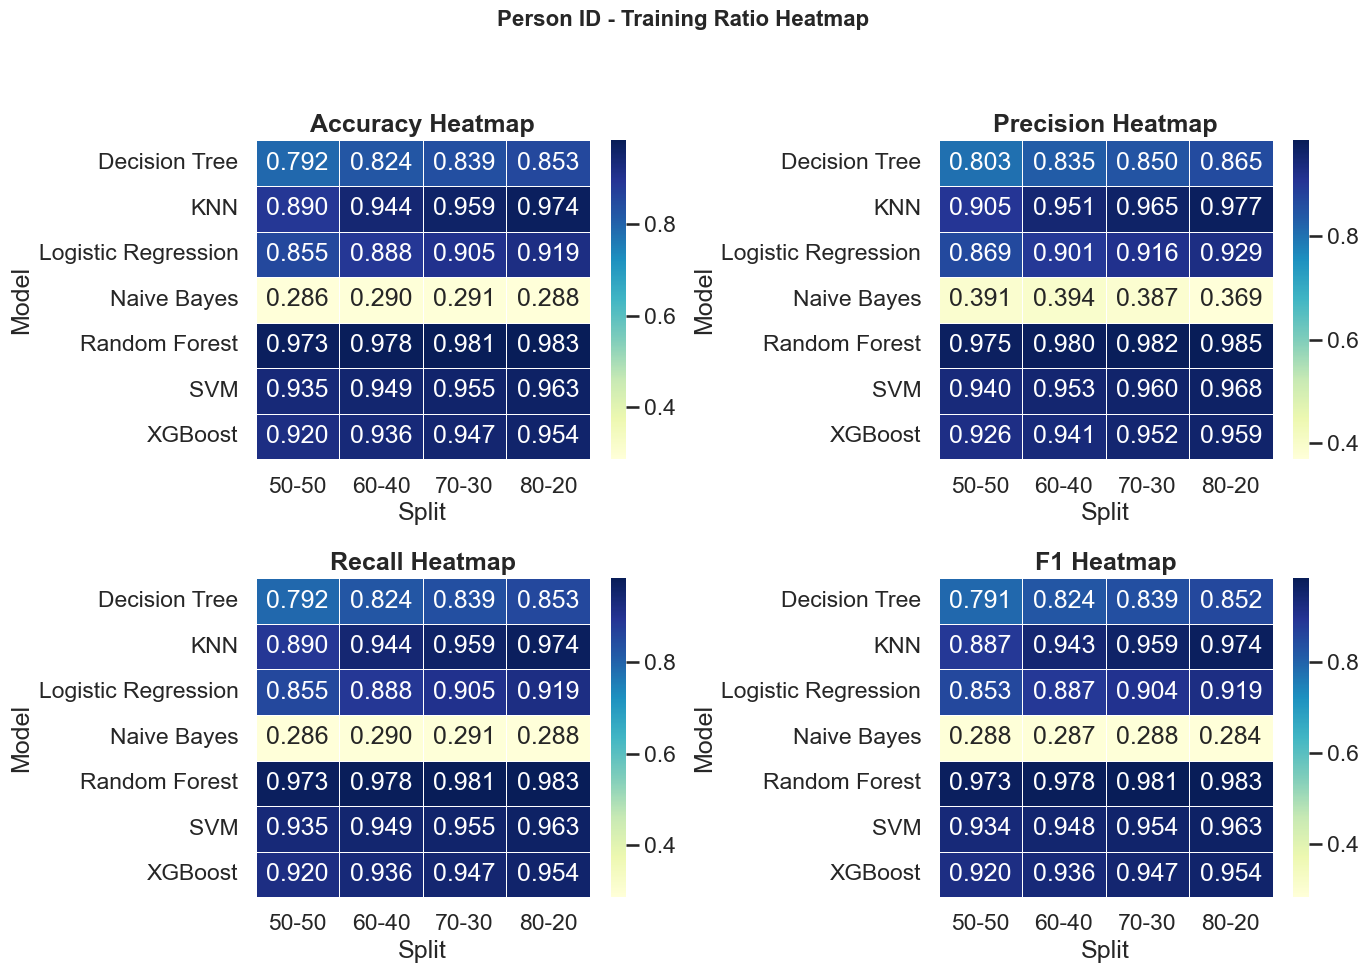

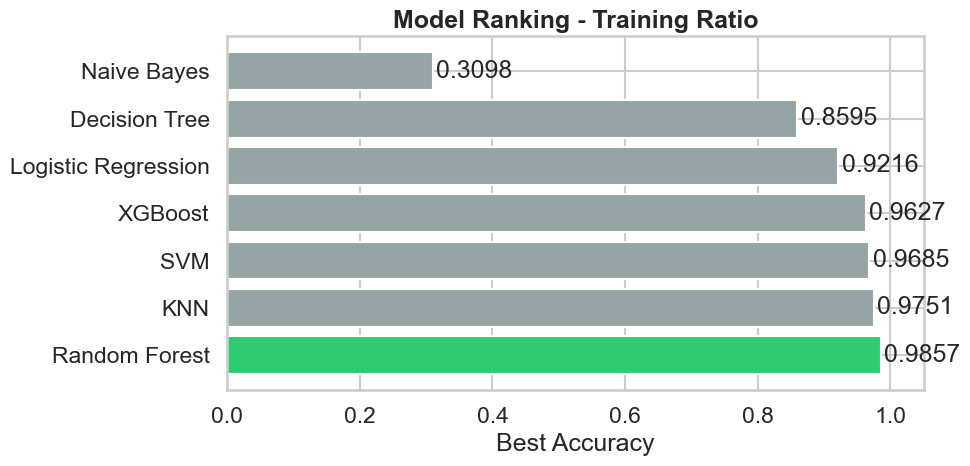

SUMMARY - Exp 2.1 - Training Ratio Variation
                           Mean_Acc  Std_Acc  Mean_Prec  Mean_Rec  Mean_F1
Model               Split                                                 
Decision Tree       50-50    0.7922   0.0122     0.8030    0.7922   0.7909
                    60-40    0.8240   0.0053     0.8345    0.8240   0.8235
                    70-30    0.8389   0.0140     0.8495    0.8389   0.8385
                    80-20    0.8531   0.0062     0.8653    0.8531   0.8523
KNN                 50-50    0.8895   0.0070     0.9048    0.8895   0.8867
                    60-40    0.9442   0.0073     0.9506    0.9442   0.9429
                    70-30    0.9594   0.0065     0.9647    0.9594   0.9591
                    80-20    0.9739   0.0015     0.9769    0.9739   0.9735
Logistic Regression 50-50    0.8547   0.0279     0.8693    0.8547   0.8533
                    60-40    0.8884   0.0102     0.9006    0.8884   0.8874
                    70-30    0.9052   0.0070     0.9155

In [11]:
m21 = df_2_1.groupby(["Split","Model"], as_index=False).mean()
bar_plot(m21, "Split", "Training Ratio", "Train-Test Split", "Exp2_1_Bar_TrainingRatio.png")
line_plot(df_2_1, "Split", "Training Ratio", "Train-Test Split", "Exp2_1_Line_TrainingRatio.png")
box_plot(df_2_1, "Split", "Training Ratio", "Exp2_1_Box_TrainingRatio.png")
heat_plot(df_2_1, "Split", "Training Ratio Heatmap", "Exp2_1_Heatmap_TrainingRatio.png")
rank_plot(df_2_1, "Training Ratio", "Exp2_1_Ranking_TrainingRatio.png")
summary_stats(df_2_1, "Split", "Exp 2.1 - Training Ratio Variation")


## Visualizations: Data Size Variation

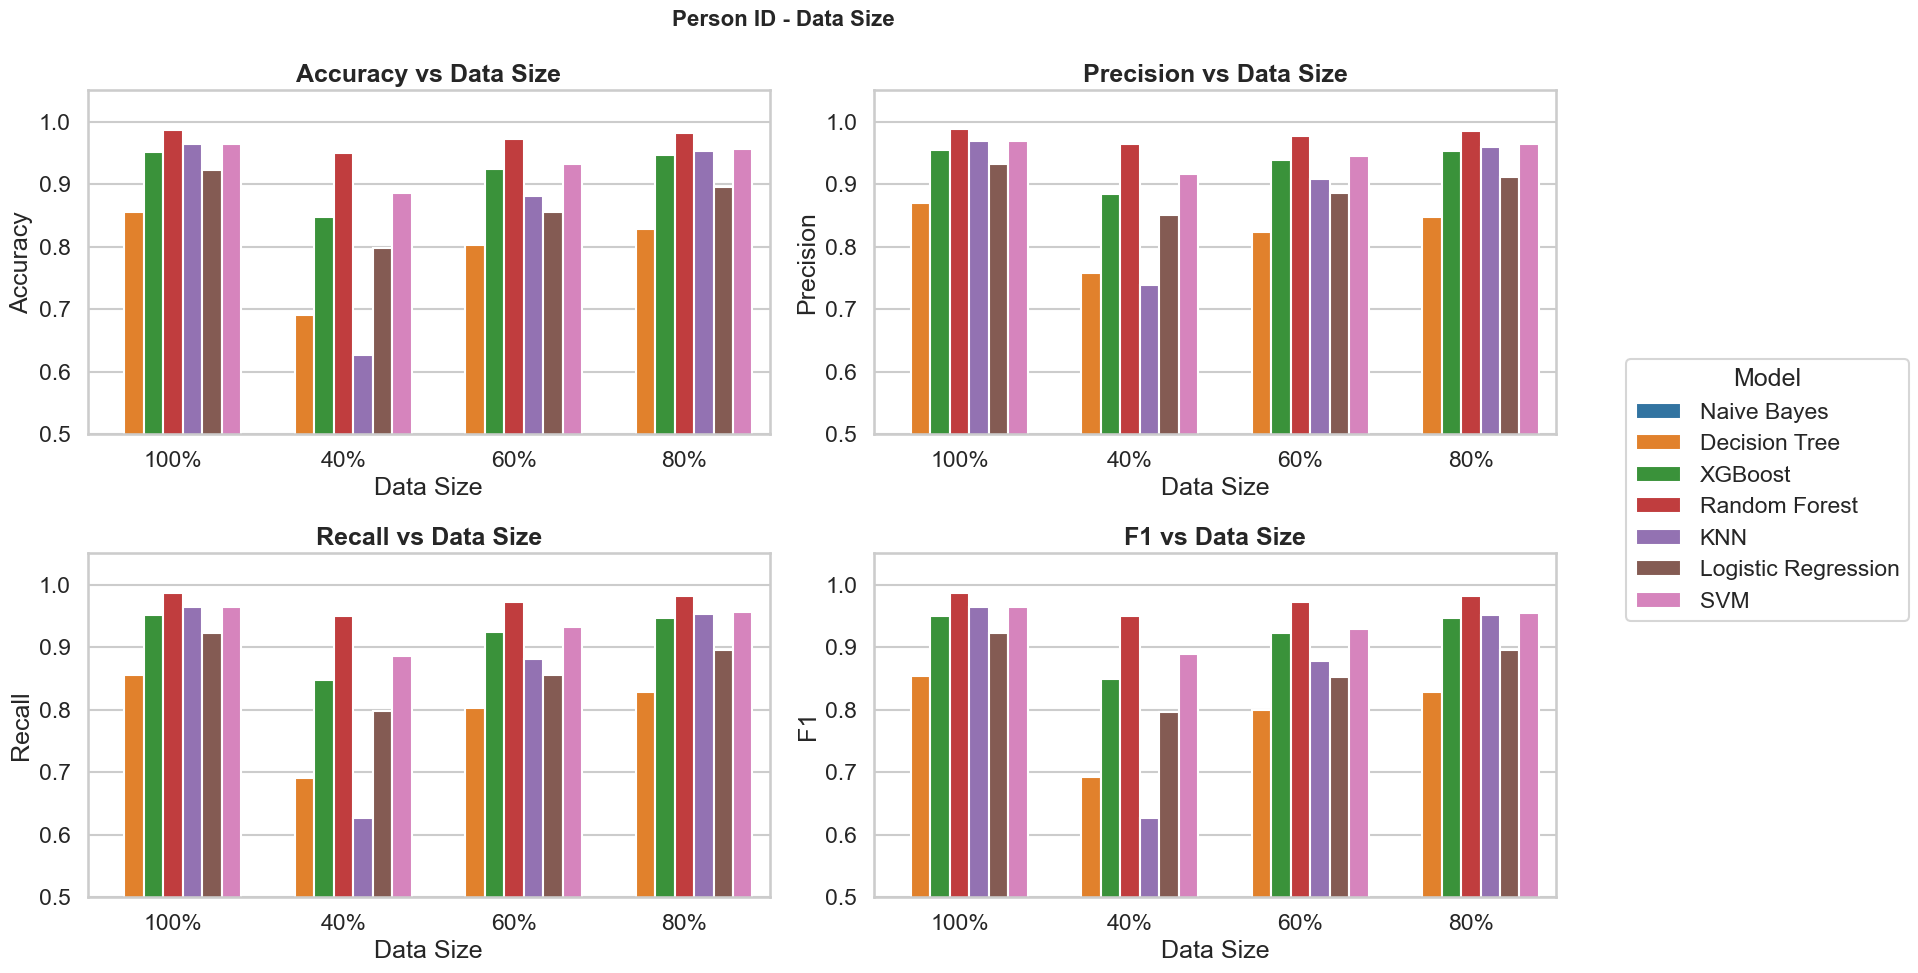

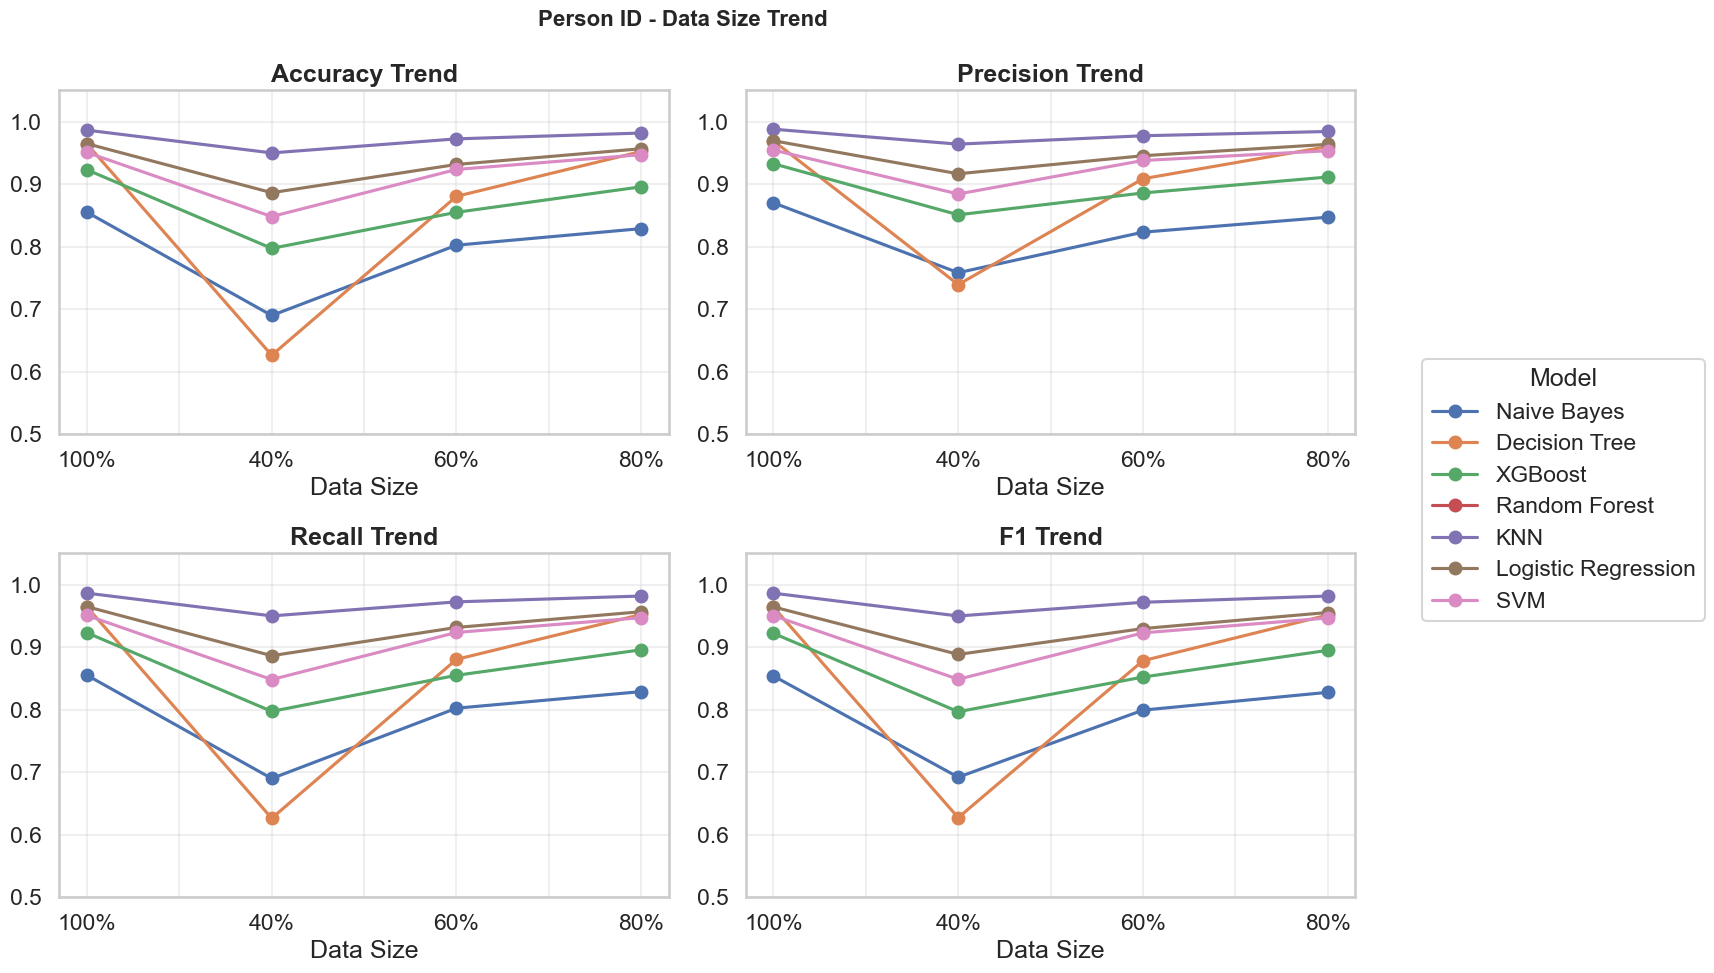

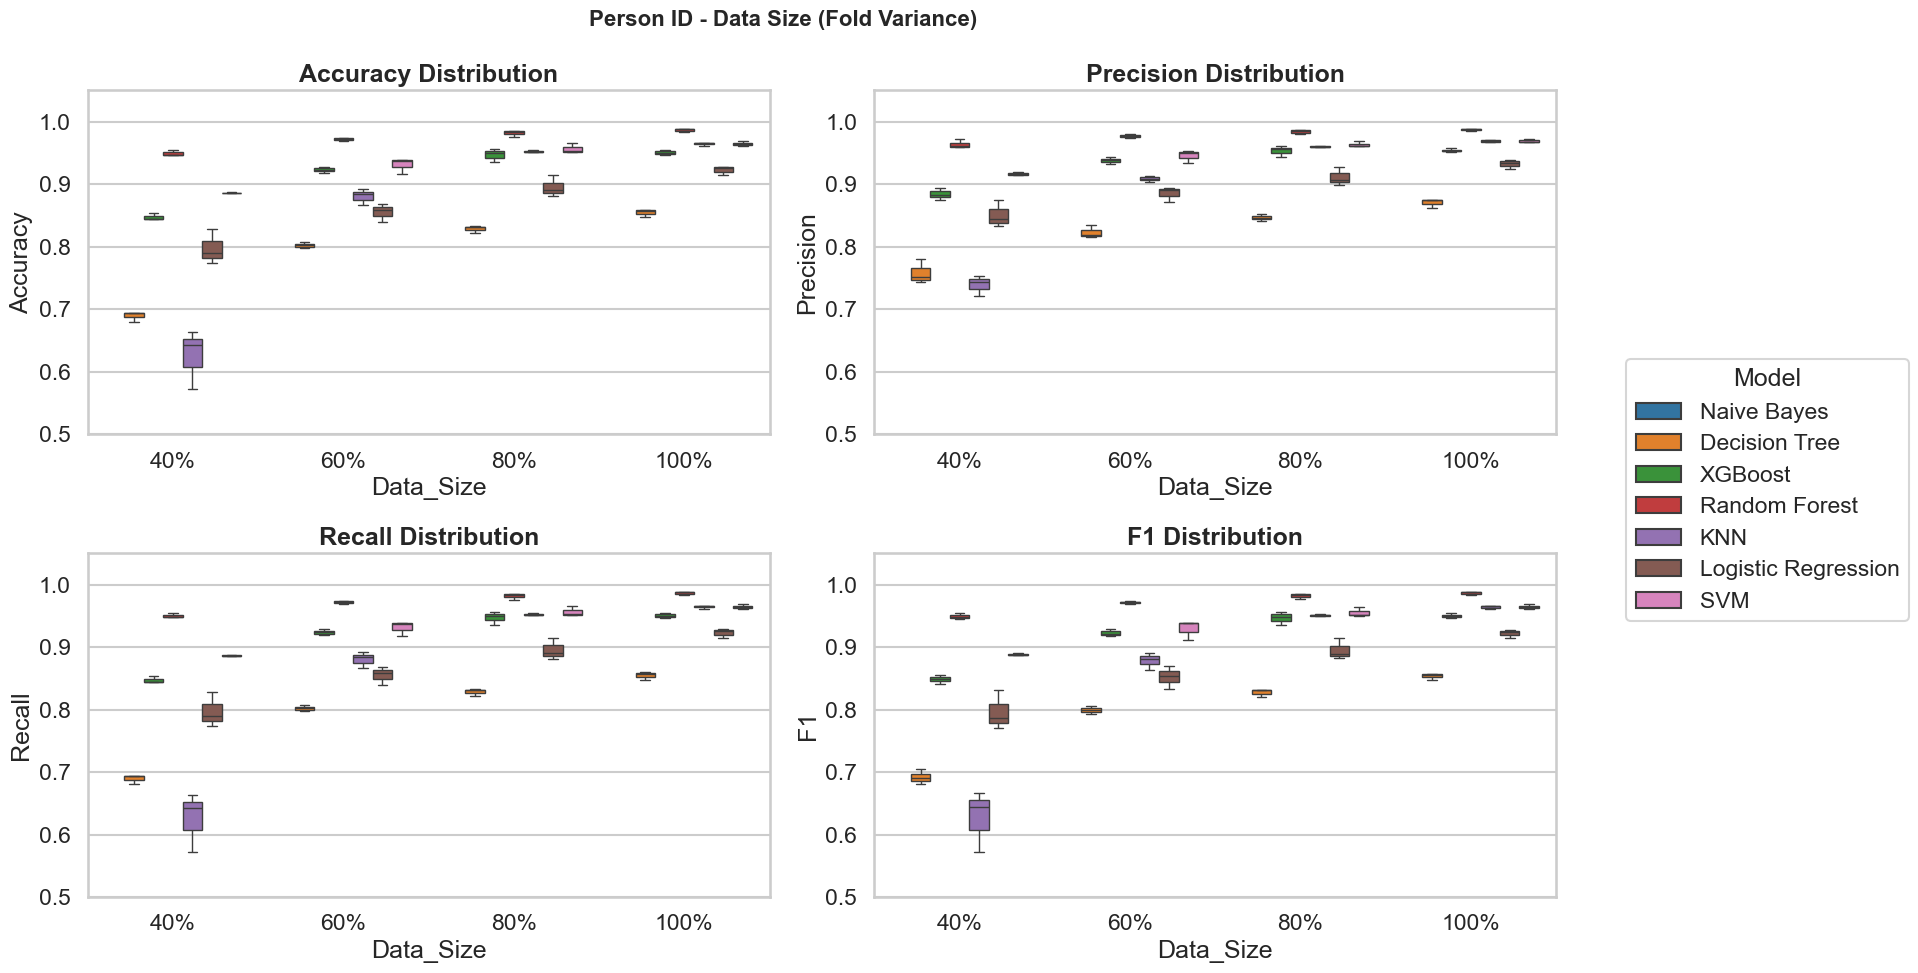

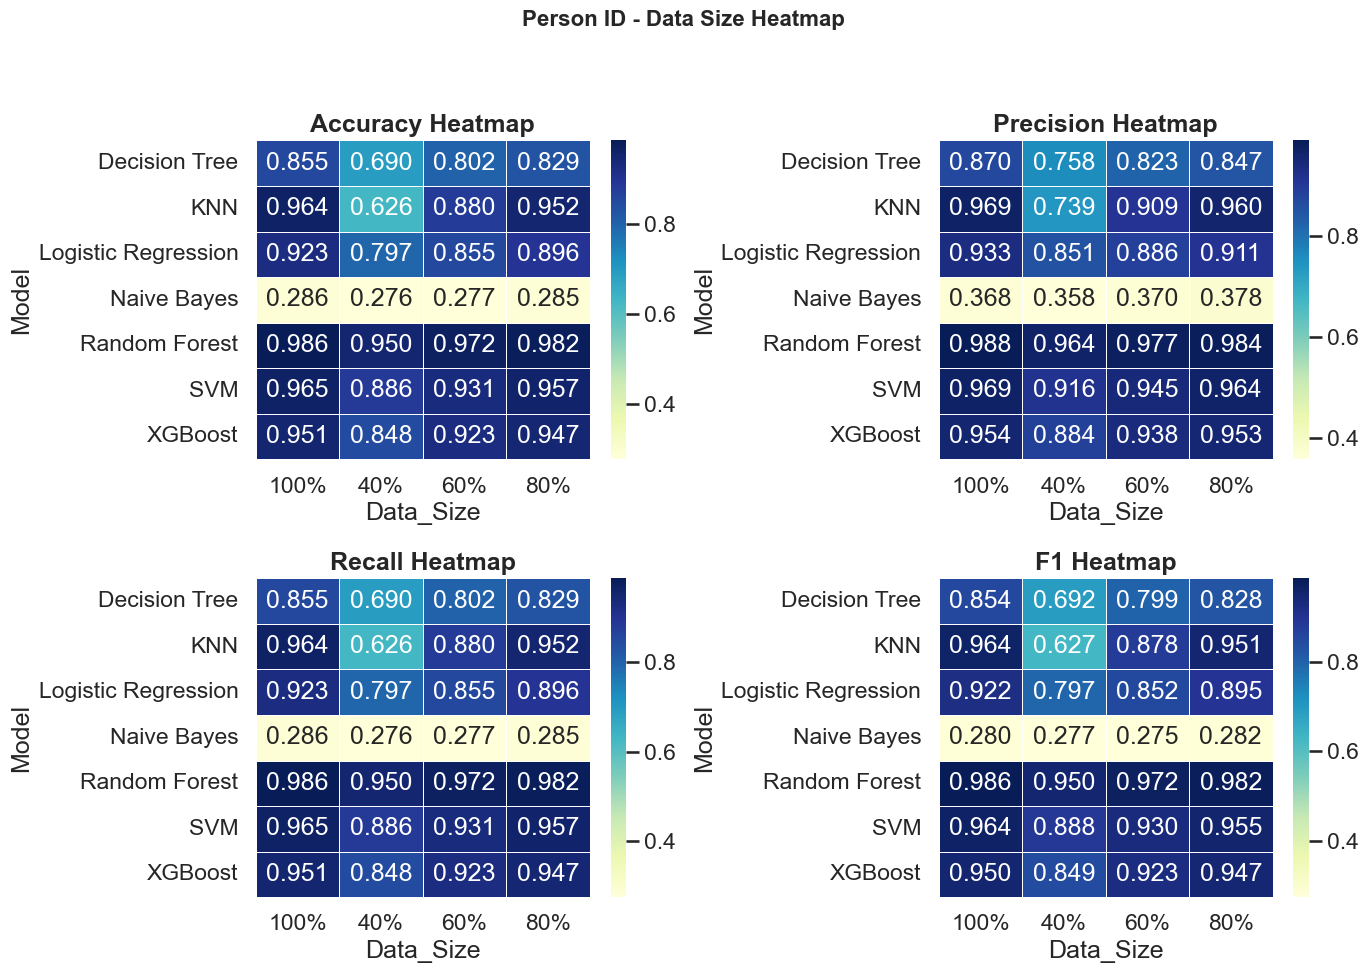

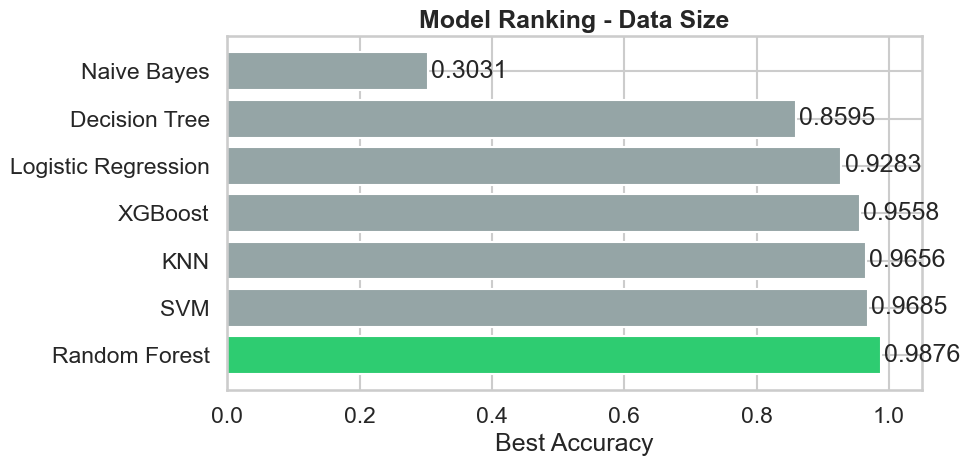

SUMMARY - Exp 2.2 - Data Size Variation
                               Mean_Acc  Std_Acc  Mean_Prec  Mean_Rec  Mean_F1
Model               Data_Size                                                 
Decision Tree       100%         0.8550   0.0061     0.8700    0.8550   0.8538
                    40%          0.6897   0.0083     0.7582    0.6897   0.6918
                    60%          0.8022   0.0048     0.8231    0.8022   0.7991
                    80%          0.8288   0.0059     0.8470    0.8288   0.8276
KNN                 100%         0.9643   0.0022     0.9691    0.9643   0.9639
                    40%          0.6261   0.0474     0.7392    0.6261   0.6271
                    60%          0.8804   0.0131     0.9086    0.8804   0.8782
                    80%          0.9522   0.0021     0.9599    0.9522   0.9513
Logistic Regression 100%         0.9229   0.0070     0.9326    0.9229   0.9220
                    40%          0.7971   0.0281     0.8508    0.7971   0.7966
            

In [12]:
m22 = df_2_2.groupby(["Data_Size","Model"], as_index=False).mean()
bar_plot(m22, "Data_Size", "Data Size", "Data Size", "Exp2_2_Bar_DataSize.png")
line_plot(df_2_2, "Data_Size", "Data Size", "Data Size", "Exp2_2_Line_DataSize.png")
box_plot(df_2_2, "Data_Size", "Data Size", "Exp2_2_Box_DataSize.png")
heat_plot(df_2_2, "Data_Size", "Data Size Heatmap", "Exp2_2_Heatmap_DataSize.png")
rank_plot(df_2_2, "Data Size", "Exp2_2_Ranking_DataSize.png")
summary_stats(df_2_2, "Data_Size", "Exp 2.2 - Data Size Variation")


## Overall Comparison & Conclusion

OVERALL BEST ACCURACY - PERSON IDENTIFICATION

By Training Ratio:
  Random Forest            : 0.9857
  KNN                      : 0.9751
  SVM                      : 0.9685
  XGBoost                  : 0.9627
  Logistic Regression      : 0.9216
  Decision Tree            : 0.8595
  Naive Bayes              : 0.3098

By Data Size:
  Random Forest            : 0.9876
  SVM                      : 0.9685
  KNN                      : 0.9656
  XGBoost                  : 0.9558
  Logistic Regression      : 0.9283
  Decision Tree            : 0.8595
  Naive Bayes              : 0.3031

Best Model Overall: Random Forest (0.9876)


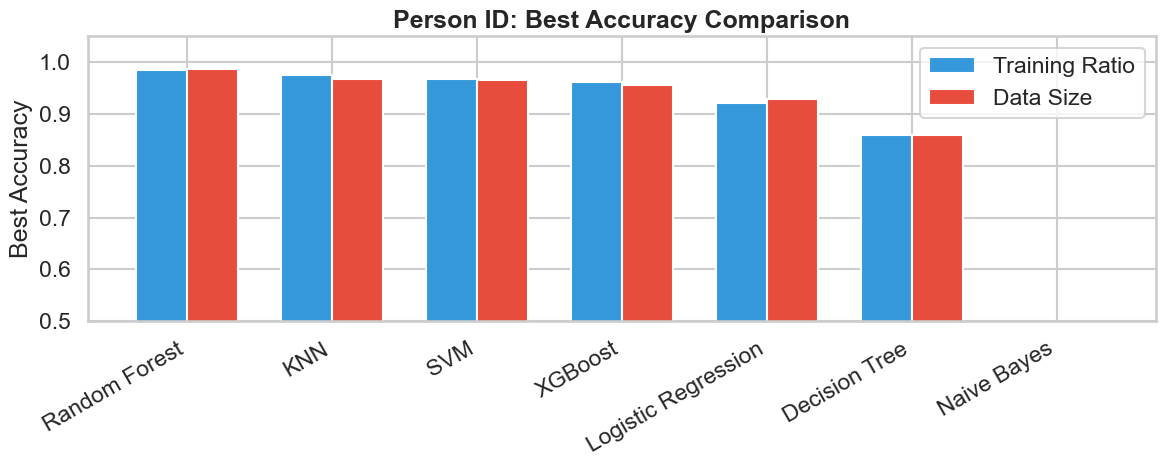

Done!


In [13]:
print("="*90); print("OVERALL BEST ACCURACY - PERSON IDENTIFICATION"); print("="*90)
b1 = df_2_1.groupby("Model")["Accuracy"].max().sort_values(ascending=False)
b2 = df_2_2.groupby("Model")["Accuracy"].max().sort_values(ascending=False)
print("\nBy Training Ratio:"); [print(f"  {m:25s}: {a:.4f}") for m,a in b1.items()]
print("\nBy Data Size:"); [print(f"  {m:25s}: {a:.4f}") for m,a in b2.items()]
all_best = pd.concat([b1,b2]).groupby(level=0).max().sort_values(ascending=False)
print(f"\nBest Model Overall: {all_best.index[0]} ({all_best.iloc[0]:.4f})")

fig,ax = plt.subplots(figsize=(12,5))
x = np.arange(len(all_best)); w = 0.35
ax.bar(x-w/2, b1.values, w, label="Training Ratio", color="#3498db")
ax.bar(x+w/2, b2.values, w, label="Data Size", color="#e74c3c")
ax.set_xticks(x); ax.set_xticklabels(all_best.index, rotation=30, ha="right")
ax.set_ylabel("Best Accuracy"); ax.set_title("Person ID: Best Accuracy Comparison", fontweight="bold")
ax.legend(); ax.set_ylim(0.5,1.05)
plt.tight_layout(); plt.savefig("Exp2_Overall_Comparison.png", dpi=300, bbox_inches='tight'); plt.show()
print("Done!")
